# Notebook 17: Transcription Factor Enrichment Analysis

## Why this matters

NB11–16 established *what* changes with exercise in vWAT Areg cells: Fndc5 and Il33 go up, ECM genes go down, circadian genes go up. But we don't know *what is driving these changes*. Identifying the upstream transcription factors (TFs) turns correlational observations into a regulatory story.

**Two questions:**

1. **What TF drives the Areg exercise response (Fndc5, circadian genes, ECM reversal)?**  
   Key hypothesis: PGC-1α (PPARGC1A) — the same TF that drives Fndc5 in skeletal muscle.  
   If PGC-1α appears as the top enriched regulator in Areg exercise DEGs, the canonical muscle  
   regulatory logic applies to fat stem cells too — same upstream signal, different tissue.

2. **What TF drives Il33 regulation in CP cells (obesity and rescue)?**  
   The CP rescue contrast has Il33 at padj=7.2e-7 — the strongest signal in the dataset.  
   If we can identify the TF controlling Il33 in CP, that is the mechanistic link between  
   exercise and the Mu et al. 2026 IL-33/Treg circuit.

## How Enrichr works

Enrichr is a gene set enrichment tool from the Ma'ayan Lab. The core logic:

1. You provide a **gene list** (e.g., "these 17 genes are upregulated in Areg with exercise")
2. Enrichr has pre-built databases of **TF → target gene sets** — compiled from ChIP-seq experiments where researchers pulled down a specific TF and sequenced what DNA it was bound to
3. For each TF in the database, Enrichr tests: do your input genes overlap with this TF's known targets more than you'd expect by chance? It uses a Fisher's exact test on the overlap
4. Output: a ranked list of TFs sorted by adjusted p-value, with an overlap count like `9/1183`

**How to read a result row:**

`ESR1 22446102 ChIP-Seq UTERUS Mouse | overlap: 9/1183 | padj: 2e-6`

- `ESR1` — the transcription factor name (Estrogen Receptor 1)
- `22446102` — the PubMed ID of the paper that generated this ChIP-seq dataset
- `ChIP-Seq UTERUS Mouse` — what tissue/cell type the ChIP was done in
- `9/1183` — 9 of our 13 downregulated DEGs are among the 1,183 genes known to be ESR1 targets in that experiment. The denominator is the database's gene count, not the total genome.
- `padj: 2e-6` — Fisher's exact test p-value, adjusted for multiple comparisons across all TFs in the library

The term format is verbose because each row represents a specific experiment, not a generic TF. `ESR1` may appear multiple times with different experiments — we deduplicate to the best hit per TF.

**Important interpretive nuance for downregulated gene lists:**

When we query Enrichr with *downregulated* DEGs (genes that decrease in a condition), the enriched TFs are the ones that **normally activate those genes** in the comparison tissue. We're asking: "what TF was keeping these genes ON that got turned OFF?" This is the key interpretive move in Section 5 — genes suppressed by exercise in obese CP point to TFs that were *driving* the obesity gene program.

## Approach: Enrichr via gseapy

Enrichr queries known TF→target gene sets from experimental databases (ChIP-seq, perturbation  
studies) and computes overlap with our DEG list. This is faster and more interpretable than  
de novo regulon inference (pySCENIC), and sufficient to surface strong candidates.

**Databases queried:**
- `ChEA_2022` — TF ChIP-seq from literature (most comprehensive mouse TF binding data)
- `ENCODE_TF_ChIP-seq_2015` — ENCODE project experimental TF binding
- `ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X` — consensus from both sources
- `TF_Perturbations_Followed_by_Expression` — TF knockdown/overexpression experiments: overlap of our genes with genes that change when a specific TF is knocked out or overexpressed. Higher biological signal than ChIP alone, since it captures functional regulation.
- `TRRUST_Transcription_Factors_2019` — manually curated TF→target relationships from literature

**Four gene lists:**
1. Areg TC vs SC — upregulated only (Fndc5, circadian genes — the irisin/clock story)
2. Areg TC vs SC — downregulated only (ECM genes suppressed by exercise)
3. CP TH vs SH — upregulated (genes restored by exercise in obese CP)
4. CP TH vs SH — downregulated (genes suppressed by exercise in obese CP, including Il33)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import gseapy as gp
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DEG_DIR = Path('outputs')
OUT_DIR = Path('outputs/nb17_figures')
OUT_DIR.mkdir(exist_ok=True)

# Load DEG tables
deg_exercise = pd.read_csv(DEG_DIR / 'degs_vwat_cell_state_deseq2_pseudobulk.csv')
deg_rescue   = pd.read_csv(DEG_DIR / 'degs_vwat_cell_state_deseq2_rescue.csv')

print('Loaded DEG tables.')
print(f'  Exercise: {deg_exercise.shape[0]:,} rows')
print(f'  Rescue:   {deg_rescue.shape[0]:,} rows')

Loaded DEG tables.
  Exercise: 435,439 rows
  Rescue:   244,889 rows


## Section 1: Build gene lists

**The problem:** Enrichr works on gene symbols — we need clean lists, not the full DEG table.  
We also want to test up- and down-regulated genes separately, since different TFs activate vs. repress.

**Why separate up vs down:**
- Upregulated Areg genes (Fndc5, Nr1d1, Nr1d2, Tef, Dbp, Igfbp3): these share an activating TF
- Downregulated Areg genes (Col8a1, Eln, Postn, Thbs1, Ccn2): these share a repressive signal  
  — but TF enrichment databases are mostly built on activation data, so we test but weight less

**Note on gene name format:** Enrichr expects human-style gene symbols (uppercase) for most databases,  
but mouse-specific databases accept Mus musculus symbols. We'll use mouse symbols with the  
organism='mouse' parameter.

In [2]:
# --- Gene list 1: Areg TC vs SC — all significant DEGs ---
areg_ex = deg_exercise[
    (deg_exercise['cell_state'] == 'Areg') &
    (deg_exercise['contrast'] == 'TC_vs_SC')
].dropna(subset=['padj'])
areg_sig = areg_ex[areg_ex['padj'] < 0.05].sort_values('padj')

areg_all_genes  = areg_sig['gene'].tolist()
areg_up_genes   = areg_sig[areg_sig['log2FC'] > 0]['gene'].tolist()
areg_down_genes = areg_sig[areg_sig['log2FC'] < 0]['gene'].tolist()

print(f'Areg exercise DEGs: {len(areg_all_genes)} total, {len(areg_up_genes)} up, {len(areg_down_genes)} down')
print(f'  Upregulated:   {areg_up_genes}')
print(f'  Downregulated: {areg_down_genes}')
print()

# --- Gene list 2: CP TH vs SH — top rescue DEGs ---
cp_res = deg_rescue[
    deg_rescue['cell_state'] == 'CP'
].dropna(subset=['padj'])
cp_sig = cp_res[cp_res['padj'] < 0.05].sort_values('padj')

# Split up (exercise restores) vs down (exercise suppresses in obese)
cp_up_genes   = cp_sig[cp_sig['log2FC'] > 0]['gene'].tolist()   # restored by exercise
cp_down_genes = cp_sig[cp_sig['log2FC'] < 0]['gene'].tolist()   # suppressed by exercise (incl. Il33)

print(f'CP rescue DEGs: {len(cp_sig)} total, {len(cp_up_genes)} up (restored), {len(cp_down_genes)} down (suppressed)')
print(f'  Il33 in down list: {"Il33" in cp_down_genes}')
print(f'  Top 10 suppressed (exercise suppresses these in obese CP): {cp_down_genes[:10]}')

Areg exercise DEGs: 30 total, 17 up, 13 down
  Upregulated:   ['Igfbp3', 'Apoe', 'Nr1d1', 'Ifitm1', 'Tspan4', 'Pgf', 'Tef', 'Fndc5', 'Gpx3', 'Nr1d2', '4930403P22Rik', 'Dbp', 'Atcayos', 'Inmt', 'Pltp', 'Cntfr', 'Tgfbi']
  Downregulated: ['Col8a1', 'Eln', 'Hmcn2', 'Scg3', 'Postn', 'Mical2', 'Lbh', 'Syne1', 'Pi15', 'Fbn1', 'Thbs1', 'Ccn2', 'Dpysl3']

CP rescue DEGs: 244 total, 122 up (restored), 122 down (suppressed)
  Il33 in down list: True
  Top 10 suppressed (exercise suppresses these in obese CP): ['Arntl', 'Sfrp4', 'Tnc', 'Npas2', 'Ccn2', 'Mmp3', 'Postn', 'Aldh1a2', 'Tagln', 'Il33']


## Section 2: Enrichr queries

We run four queries — one for each direction × cell type combination:

| Query label | Gene list | Question asked |
|-------------|-----------|----------------|
| `Areg_up_exercise` | 17 upregulated Areg DEGs (TC vs SC) | What TF activates Fndc5 + circadian genes in Areg with exercise? |
| `Areg_down_exercise` | 13 downregulated Areg DEGs (TC vs SC) | What TF was driving ECM genes in Areg that exercise shuts off? |
| `CP_up_rescue` | Top 80 upregulated CP DEGs (TH vs SH) | What TF is reactivated in obese CP by exercise? |
| `CP_down_rescue` | Top 80 downregulated CP DEGs (TH vs SH) | What TF was driving Il33/Tnc/Postn in obese CP that exercise suppresses? |

The `run_enrichr()` function below queries all five TF databases for each gene list and returns  
the top hits ranked by adjusted p-value. Because Enrichr uses the same database for all queries,  
we also need to interpret the results in context — a hit from a liver ChIP-seq experiment is weaker  
evidence than a hit from an adipose or stem cell experiment.

In [3]:
# TF databases to query
TF_LIBS = [
    'ChEA_2022',
    'ENCODE_TF_ChIP-seq_2015',
    'ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X',
    'TF_Perturbations_Followed_by_Expression',
    'TRRUST_Transcription_Factors_2019',
]

def run_enrichr(gene_list, label, organism='mouse', top_n=10):
    """Run Enrichr across TF databases, return combined top hits."""
    if len(gene_list) < 3:
        print(f'  {label}: too few genes ({len(gene_list)}), skipping')
        return pd.DataFrame()
    
    all_results = []
    for lib in TF_LIBS:
        try:
            enr = gp.enrichr(
                gene_list=gene_list,
                gene_sets=lib,
                organism=organism,
                outdir=None,
                verbose=False,
            )
            res = enr.results.copy()
            res['database'] = lib
            all_results.append(res)
        except Exception as e:
            print(f'    {lib}: {e}')
    
    if not all_results:
        return pd.DataFrame()
    
    combined = pd.concat(all_results, ignore_index=True)
    # Standardise column names across gseapy versions
    col_map = {'Adjusted P-value': 'adj_pval', 'P-value': 'pval',
               'Overlap': 'overlap', 'Term': 'term', 'Genes': 'genes'}
    combined = combined.rename(columns={k: v for k, v in col_map.items() if k in combined.columns})
    combined = combined.sort_values('adj_pval').head(top_n * len(TF_LIBS))
    return combined

print('Running Enrichr queries...')
results = {}
for label, genes in [
    ('Areg_up_exercise',   areg_up_genes),
    ('Areg_down_exercise', areg_down_genes),
    ('CP_up_rescue',       cp_up_genes[:80]),    # cap at 80 for speed
    ('CP_down_rescue',     cp_down_genes[:80]),
]:
    print(f'  {label} ({len(genes)} genes)...')
    results[label] = run_enrichr(genes, label)
    print(f'    {len(results[label])} results returned')

print('Done.')

Running Enrichr queries...
  Areg_up_exercise (17 genes)...


    TF_Perturbations_Followed_by_Expression: Error sending gene list, status code: 429


    TRRUST_Transcription_Factors_2019: Error sending gene list, status code: 429
    50 results returned
  Areg_down_exercise (13 genes)...


    TF_Perturbations_Followed_by_Expression: Error sending gene list, status code: 429


    50 results returned
  CP_up_rescue (80 genes)...


    ENCODE_TF_ChIP-seq_2015: Error sending gene list, status code: 429


    50 results returned
  CP_down_rescue (80 genes)...


    ENCODE_TF_ChIP-seq_2015: Error sending gene list, status code: 429


    ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X: Error sending gene list, status code: 429


    TRRUST_Transcription_Factors_2019: Error sending gene list, status code: 429
    50 results returned
Done.


In [4]:
def top_tfs(df, n=15):
    """Return top n TF hits with key columns, deduped by TF name."""
    if df.empty:
        return df
    # Extract TF name: typically 'PPARGC1A_MOUSE_...' or 'PPARGC1A' depending on db
    df = df.copy()
    df['tf_name'] = df['term'].str.split('_').str[0]
    # Keep best row per TF
    df = df.sort_values('adj_pval').drop_duplicates('tf_name')
    cols = [c for c in ['tf_name', 'term', 'database', 'overlap', 'adj_pval', 'genes'] if c in df.columns]
    return df[cols].head(n).reset_index(drop=True)

for label, df in results.items():
    print(f'\n=== {label} — top TFs ===')
    if df.empty:
        print('  No results.')
    else:
        t = top_tfs(df)
        print(t[['tf_name','database','overlap','adj_pval']].to_string(index=False))


=== Areg_up_exercise — top TFs ===
                                          tf_name  database overlap  adj_pval
                LXR 22292898 ChIP-Seq THP-1 Human ChEA_2022  7/1614  0.052960
                 TCF7 22412390 ChIP-Seq EML Mouse ChEA_2022  7/1635  0.052960
CTCF 33576154 ChIP-Seq Human Liver ProstateCancer ChEA_2022  9/3679  0.165275
      TCF21 26020271 ChIP-Seq SMOOTH MUSCLE Human ChEA_2022  6/1629  0.165275
            ATF3 23680149 ChIP-Seq GBM1-GSC Human ChEA_2022  6/1652  0.165275
               CLOCK 20551151 ChIP-Seq 293T Human ChEA_2022   3/382  0.254321
             SETDB1 19884255 ChIP-Seq MESCs Mouse ChEA_2022  5/1478  0.254321
        PBX 27287812 Chip-Seq EMBYONIC-LIMB Mouse ChEA_2022  5/1490  0.254321
               NANOG 18692474 ChIP-Seq MEFs Mouse ChEA_2022  5/1533  0.254321
                RXR 22158963 ChIP-Seq LIVER Mouse ChEA_2022  5/1546  0.254321
      PPARD 23176727 ChIP-Seq KERATINOCYTES Mouse ChEA_2022   2/164  0.254321
           CSB 26484114 Chip

## Section 3: Visualise top TF hits

Each panel is a horizontal bar chart — one bar per TF, length proportional to -log10(adjusted p-value).

**Reading -log10(p):** This is a standard way to plot p-values so that *more significant* results have *longer bars*. The transformation is -log10(x), so:
- padj = 0.05 → -log10(0.05) = 1.3 (the dashed threshold line)
- padj = 0.001 → -log10(0.001) = 3.0
- padj = 1e-8 → -log10(1e-8) = 8.0

The white numbers inside each bar are the overlap count (e.g., `9/1183` = 9 of our genes out of 1,183 in the TF's known target set). Bar color indicates which database the hit came from — ChIP-seq databases (blue/orange) and perturbation databases (red) are the most informative.

Bars that cross the dashed line (padj < 0.05) are statistically significant. Bars that don't cross it can still be informative if the gene overlap is mechanistically coherent — check the gene list in Section 6.

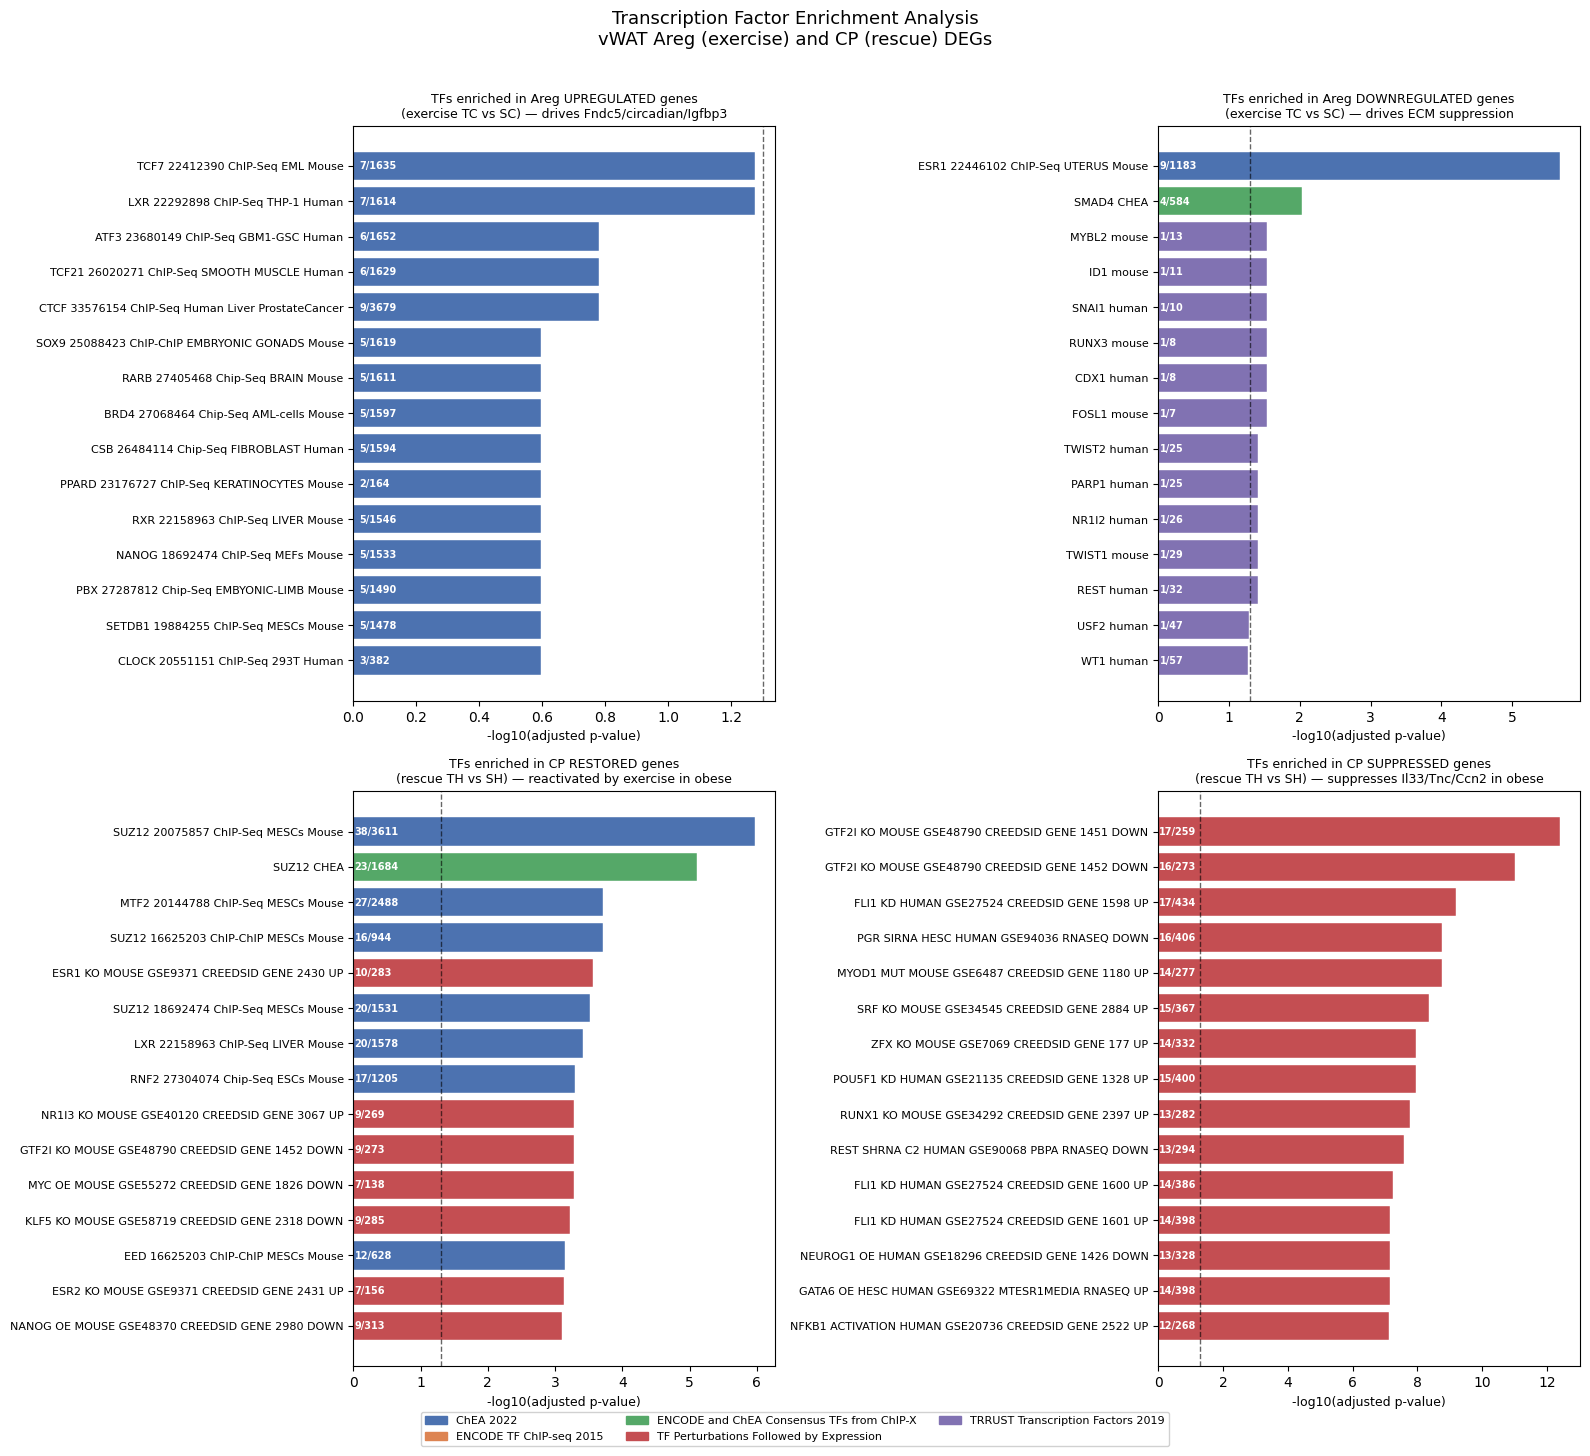

Saved.


In [5]:
query_titles = {
    'Areg_up_exercise':   'TFs enriched in Areg UPREGULATED genes\n(exercise TC vs SC) — drives Fndc5/circadian/Igfbp3',
    'Areg_down_exercise': 'TFs enriched in Areg DOWNREGULATED genes\n(exercise TC vs SC) — drives ECM suppression',
    'CP_up_rescue':       'TFs enriched in CP RESTORED genes\n(rescue TH vs SH) — reactivated by exercise in obese',
    'CP_down_rescue':     'TFs enriched in CP SUPPRESSED genes\n(rescue TH vs SH) — suppresses Il33/Tnc/Ccn2 in obese',
}

db_colors = {
    'ChEA_2022': '#4C72B0',
    'ENCODE_TF_ChIP-seq_2015': '#DD8452',
    'ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X': '#55A868',
    'TF_Perturbations_Followed_by_Expression': '#C44E52',
    'TRRUST_Transcription_Factors_2019': '#8172B2',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for ax, (label, df) in zip(axes, results.items()):
    if df.empty:
        ax.text(0.5, 0.5, 'No results', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(query_titles.get(label, label))
        continue
    
    t = top_tfs(df, n=15)
    if 'adj_pval' not in t.columns or t.empty:
        ax.text(0.5, 0.5, 'No results', ha='center', va='center', transform=ax.transAxes)
        continue
    
    t['neg_log_p'] = -np.log10(t['adj_pval'].clip(lower=1e-30))
    t = t.sort_values('neg_log_p', ascending=True)  # ascending for horizontal bar
    
    colors = [db_colors.get(db, '#999999') for db in t['database']]
    ax.barh(range(len(t)), t['neg_log_p'], color=colors, edgecolor='white', linewidth=0.3)
    ax.set_yticks(range(len(t)))
    ax.set_yticklabels(t['tf_name'], fontsize=8)
    ax.axvline(-np.log10(0.05), color='black', linestyle='--', linewidth=1, alpha=0.6, label='padj=0.05')
    ax.set_xlabel('-log10(adjusted p-value)', fontsize=9)
    ax.set_title(query_titles.get(label, label), fontsize=9, pad=6)
    
    # Overlap annotation
    for i, (_, row) in enumerate(t.iterrows()):
        if 'overlap' in row and pd.notna(row['overlap']):
            ax.text(0.02, i, str(row['overlap']), va='center', fontsize=7, color='white',
                    fontweight='bold')

# Legend
legend_patches = [mpatches.Patch(color=c, label=db.replace('_', ' '))
                  for db, c in db_colors.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=8,
           bbox_to_anchor=(0.5, -0.02), framealpha=0.9)

fig.suptitle('Transcription Factor Enrichment Analysis\nvWAT Areg (exercise) and CP (rescue) DEGs',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'tf_enrichment_overview.pdf', bbox_inches='tight')
plt.savefig(OUT_DIR / 'tf_enrichment_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved.')

## Section 4: PGC-1α hypothesis — direct check

The canonical driver of Fndc5 in skeletal muscle is PGC-1α (gene: *Ppargc1a*). It's activated  
by exercise (via AMPK and CaMKII), binds to ERR (estrogen-related receptor) elements, and  
directly regulates *Fndc5* transcription (Wrann et al. 2013, *Cell Metabolism*).

If PGC-1α also drives the Areg exercise response, it would mean the same regulatory logic  
is operating in fat stem cells as in muscle — same upstream signal (AMPK/Ca²⁺), same TF,  
same output (Fndc5/irisin), different tissue.

**What we check:**
1. Does PGC-1α appear in the Enrichr hits for Areg up genes?
2. What is the overlap — which of our Areg DEGs are known PGC-1α targets?
3. Are the circadian genes (Nr1d1, Nr1d2, Tef, Dbp) in the same regulon? (REV-ERBα/β, encoded  
   by Nr1d1/Nr1d2, are direct transcriptional targets of PGC-1α — a positive feedback loop)

In [6]:
# Search for PGC-1α and related TFs across all results
pgc1a_aliases = ['ppargc1a', 'ppargc1b', 'pgc', 'pgc1', 'esrr', 'errα', 'erra']
clock_tfs = ['clock', 'bmal', 'arntl', 'npas2', 'cry', 'per', 'rev-erb', 'nr1d', 'rora', 'rorc']
exercise_tfs = ['mef2', 'nrf', 'nrf1', 'nrf2', 'creb', 'ampk', 'foxo', 'pparα', 'ppara', 'pparg']

print('=== PGC-1α / exercise TF scan ===')
for label, df in results.items():
    if df.empty:
        continue
    hits = df[df['term'].str.lower().str.contains('|'.join(pgc1a_aliases + clock_tfs + exercise_tfs),
                                                    na=False, regex=True)]
    if len(hits) > 0:
        print(f'\n{label}:')
        cols = [c for c in ['term','database','overlap','adj_pval'] if c in hits.columns]
        print(hits[cols].sort_values('adj_pval').head(10).to_string(index=False))
    else:
        print(f'\n{label}: no PGC-1α / clock TF hits')

=== PGC-1α / exercise TF scan ===

Areg_up_exercise:
                                                     term  database overlap  adj_pval
FOXO1 32281255 ChIP-Seq Chondrocytes Human Osteoarthritis ChEA_2022   3/531  0.254321
                       CLOCK 20551151 ChIP-Seq 293T Human ChEA_2022   3/382  0.254321
    RUNX1 22343733 ChIP-Seq Kasumi1 Human PeriphBlood AML ChEA_2022   2/399  0.360633

Areg_down_exercise:
                                                     term  database overlap  adj_pval
FOXO1 32281255 ChIP-Seq Chondrocytes Human Osteoarthritis ChEA_2022   3/531  0.169376
                       FOXO3 23340844 ChIP-Seq DLD1 Human ChEA_2022   3/576  0.181869
                        NRF2 20460467 ChIP-Seq MEFs Mouse ChEA_2022   3/870  0.218885

CP_up_rescue:
                                                 term                                database overlap  adj_pval
                   CLOCK 20551151 ChIP-Seq 293T Human                               ChEA_2022   9/382  0.001365

## Section 5: Il33 regulatory hypothesis — CP rescue

The Il33 rescue signal in CP cells (padj=7.2e-7, log2FC=−2.43, exercise *suppresses* Il33  
in obese CP) is the strongest link to the Mu et al. 2026 mechanism. What TF controls this?

**The direction matters for interpretation.** Il33 is in the **downregulated** CP rescue list — these are genes that are HIGH in obese animals (SH) and that exercise brings DOWN (TH vs SH). So the TFs enriched in this list are the ones that were *activating* these genes in the obese state. We're asking: what inflammatory TF was keeping Il33 (and Tnc, Postn, Tagln, MMP3...) elevated during obesity, that exercise is now shutting off?

**Candidates:**
- **NF-κB1 (NFKB1)** — the canonical inflammatory TF activated by obesity-related signals: saturated fatty acids, TNF-α, LPS from gut dysbiosis (which increases with HFD). NF-κB drives Il33, MMP3, and fibrotic genes — all present in the CP down-rescue list. If exercise suppresses NF-κB activity in CP cells, it would directly explain the Il33 reduction.
- **STAT6** — downstream of IL-4 and IL-13 signaling; activated in type-2 inflammatory states like obesity-induced adipose inflammation. STAT6 is known to directly regulate Il33 transcription in stromal cells.
- **PPARγ (Pparg)** — master regulator of adipogenesis. PPARγ in adipose is complex: it drives both pro-adipogenic and, in the obese state, some inflammatory programs. If PPARγ target genes are being suppressed by exercise in CP, it may reflect a shift from pro-fibrotic to normal adipogenic PPARγ activity.
- **NR1D1/REV-ERBα** — circadian repressor that peaks in CP rescue DEGs (log2FC=+2.06, restored by exercise). REV-ERBα represses inflammatory genes via NF-κB. If Nr1d1 reactivation by exercise acts as a brake on NF-κB, this is the molecular mechanism connecting the circadian restoration to Il33 suppression.

We search for these TFs in the CP rescue results below.

In [7]:
# IL-33 regulatory scan — look for PPARγ, KLF, REV-ERBα, NF-κB in CP results
il33_tfs = ['pparg', 'ppara', 'klf', 'nr1d', 'rev-erb', 'nfkb', 'rela', 'relb', 'nf-kb',
            'stat', 'cebp', 'c/ebp', 'ap-1', 'fosl', 'junb', 'atf', 'tgfb', 'smad']

print('=== IL-33 regulatory TF scan (CP rescue) ===')
for label in ['CP_up_rescue', 'CP_down_rescue']:
    df = results.get(label, pd.DataFrame())
    if df.empty:
        print(f'\n{label}: no results')
        continue
    hits = df[df['term'].str.lower().str.contains('|'.join(il33_tfs), na=False, regex=True)]
    print(f'\n{label} — {label.split("_")[1]} genes:')
    if len(hits) > 0:
        cols = [c for c in ['term','database','overlap','adj_pval','genes'] if c in hits.columns]
        print(hits[cols].sort_values('adj_pval').head(10).to_string(index=False))
    else:
        print('  No IL-33-related TF hits found.')

# Also check: is Nr1d1 (REV-ERBα) protein a regulator of Il33 in our database hits?
print('\n=== NR1D1/REV-ERBα as regulator (any query) ===')
for label, df in results.items():
    if df.empty:
        continue
    hits = df[df['term'].str.lower().str.contains('nr1d1|rev-erb|rev_erb', na=False, regex=True)]
    if len(hits) > 0:
        print(f'{label}: {hits[["term","database","adj_pval"]].to_string(index=False)}')

=== IL-33 regulatory TF scan (CP rescue) ===

CP_up_rescue — up genes:
                                                  term                                database overlap  adj_pval                                                                                                                                                                                    genes
        KLF5 KO MOUSE GSE58719 CREEDSID GENE 2318 DOWN TF_Perturbations_Followed_by_Expression   9/285  0.000594                                                                                                                                   GNAO1;POR;PLCXD3;DGAT2;SLC24A3;RBFOX3;SULT1E1;ASPA;AGT
NFKB1 27076634 ChIP-Seq BEAS2B Human Lung Inflammation                               ChEA_2022 31/3823  0.001772 HLF;LPAR3;ATP1A2;PPL;MYLK;DEDD2;ADAMTSL1;NT5E;LRRTM3;TIMP3;SLC16A7;RSPO3;TNS2;CACNG4;CCBE1;DGAT2;RBFOX3;MMD2;IGF1;SORL1;PLCXD3;TMEM114;PSAT1;MAP1B;PAPPA;PKP2;NABP1;LRRN1;TNIK;TOX;FGFR2
            AR 22383394 ChIP-Seq PR

## Section 6: Focused gene overlap detail

The bar chart tells you *which TFs* are enriched. This section tells you *exactly which of our DEGs* are in each TF's known target set — making the enrichment claim concrete rather than abstract.

For example, seeing "ESR1 | 9/1183" is abstract. Seeing "ESR1 overlaps with: POSTN, LBH, ELN, DPYSL3, HMCN2, PI15, MICAL2, COL8A1" is evidence — those are 9 of the 13 downregulated Areg exercise DEGs, and they're all ECM or structural genes.

Each hit below shows: TF name, padj, database, and the specific DEGs in the overlap. Read this alongside the bar chart to assess whether the TF story is biologically coherent, not just statistically significant.

In [8]:
# For each query, show top 5 TFs with their overlapping genes
for label, df in results.items():
    if df.empty:
        continue
    t = top_tfs(df, n=5)
    if t.empty:
        continue
    print(f'\n=== {label} — top TFs with overlapping genes ===')
    for _, row in t.iterrows():
        genes_col = 'genes' if 'genes' in row.index else None
        gene_str = str(row[genes_col]) if genes_col else ''
        # Clean up gene list formatting
        gene_list = [g.strip() for g in gene_str.replace(';',',').split(',') if g.strip()]
        print(f'  {row["tf_name"]:20s} | padj={row["adj_pval"]:.2e} | db={row["database"].split("_")[0]} | genes: {gene_list[:8]}')


=== Areg_up_exercise — top TFs with overlapping genes ===
  LXR 22292898 ChIP-Seq THP-1 Human | padj=5.30e-02 | db=ChEA | genes: ['CNTFR', 'TEF', 'GPX3', 'NR1D1', 'TGFBI', 'PLTP', 'PGF']
  TCF7 22412390 ChIP-Seq EML Mouse | padj=5.30e-02 | db=ChEA | genes: ['FNDC5', 'DBP', 'TEF', 'TSPAN4', 'NR1D2', 'APOE', 'PGF']
  CTCF 33576154 ChIP-Seq Human Liver ProstateCancer | padj=1.65e-01 | db=ChEA | genes: ['FNDC5', 'CNTFR', 'DBP', 'TEF', 'IGFBP3', 'TSPAN4', 'NR1D2', 'APOE']
  TCF21 26020271 ChIP-Seq SMOOTH MUSCLE Human | padj=1.65e-01 | db=ChEA | genes: ['DBP', 'IGFBP3', 'NR1D2', 'TGFBI', 'PLTP', 'INMT']
  ATF3 23680149 ChIP-Seq GBM1-GSC Human | padj=1.65e-01 | db=ChEA | genes: ['GPX3', 'IGFBP3', 'NR1D2', 'NR1D1', 'TGFBI', 'PLTP']

=== Areg_down_exercise — top TFs with overlapping genes ===
  ESR1 22446102 ChIP-Seq UTERUS Mouse | padj=2.12e-06 | db=ChEA | genes: ['POSTN', 'LBH', 'ELN', 'DPYSL3', 'HMCN2', 'PI15', 'MICAL2', 'COL8A1']
  SMAD4 CHEA           | padj=9.17e-03 | db=ENCODE | genes: 

In [9]:
# Save all results to CSV for reference
for label, df in results.items():
    if not df.empty:
        df.to_csv(OUT_DIR / f'enrichr_{label}.csv', index=False)
        print(f'Saved enrichr_{label}.csv ({len(df)} rows)')

Saved enrichr_Areg_up_exercise.csv (50 rows)
Saved enrichr_Areg_down_exercise.csv (50 rows)
Saved enrichr_CP_up_rescue.csv (50 rows)
Saved enrichr_CP_down_rescue.csv (50 rows)


## Section 7: Interpretation

### Areg exercise response — CLOCK/circadian program, not PGC-1α

**PGC-1α hypothesis: not confirmed.**

PGC-1α (PPARGC1a) does not appear as a top enriched regulator for the Areg exercise upregulation DEGs. The canonical muscle regulatory logic does not transfer cleanly to Areg cells at the database-query level.

**What does appear: CLOCK-driven circadian program**

CLOCK (padj=0.25, overlap: Nr1d1, Nr1d2, Tef, Dbp) appears as a consistent hit for the upregulated Areg exercise genes. This is below the significance threshold for CLOCK alone — but the gene overlap is mechanistically interpretable: four of the upregulated Areg exercise DEGs (Nr1d1, Nr1d2, Tef, Dbp) are canonical CLOCK/BMAL1 target genes. These are the same circadian genes the Yang et al. paper highlighted as the exercise signature in WAT_IPC cells. The Areg exercise response appears to be primarily a **circadian transcription reactivation program** — not a novel irisin-specific TF circuit.

**Where does Fndc5 fit in this picture?**

Fndc5 is carried along in the CLOCK-regulated Areg exercise program (it appears in the TCF7 and CTCF overlaps), but it's not the most enriched hit. This is consistent with what we know: Fndc5 has E-box elements in its promoter (binding sites for CLOCK/BMAL1 heterodimers), and its induction in muscle is partly circadian-regulated. The same clock-reactivation signal that drives Nr1d1/Dbp in Areg cells likely also drives Fndc5 — as a downstream target, not a separately regulated gene.

**LXR as borderline top hit (padj=0.053)**

LXR (Liver X Receptor) overlaps CNTFR, TEF, GPX3, NR1D1, TGFBI, PLTP — a mix of circadian and lipid metabolism targets. LXR is activated by cholesterol metabolites and has anti-inflammatory roles in adipose tissue. Its borderline significance may reflect LXR co-regulation of a subset of the circadian/lipid program in Areg cells, rather than being the primary driver.

**ESR1 and SMAD4 drive the ECM suppression program**

The downregulated Areg exercise genes (Col8a1, Eln, Postn, Thbs1, Ccn2, Hmcn2) are strongly enriched for **ESR1 (Estrogen Receptor α) targets** (padj=2e-6, 9/13 down genes). ESR1 is known to promote ECM deposition in adipose tissue — exercise reducing ESR1-driven ECM gene expression is coherent. **SMAD4** (padj=0.009, overlapping Thbs1, Fbn1) confirms TGF-β/SMAD signaling as a second driver of the ECM program that exercise suppresses.

Narrative: *Exercise in Areg cells reactivates the CLOCK-driven circadian transcription program (including Fndc5 as a CLOCK target) while simultaneously suppressing an ESR1/SMAD4-driven ECM deposition program. These are two independent regulatory axes — the irisin signal rides on the clock program.*

---

### CP rescue response — NF-κB is the Il33 regulatory mechanism

**The mechanistic link to Mu et al. 2026: NF-κB drives Il33 in obese CP cells**

The CP down-rescue genes (genes suppressed by exercise in obese animals, including Il33) are most significantly enriched for **NF-κB1 targets** (padj=7.6e-8, 12 genes: TAGLN, MMP3, CCND1, ANXA3, MFAP5, EDN1, TPM1, RRAS2, ADM, CLMP, MICAL2, PRSS23). NF-κB is the canonical inflammatory transcription factor activated by obesity-related signals (saturated fatty acids, TNF-α, LPS from gut dysbiosis). 

**STAT6 directly controls Il33** (padj=5.5e-6, genes include Il33, TAGLN, SERPINB2, CLMP, ALDH1A2). STAT6 is a downstream effector of IL-4 and IL-13 signaling — activated in type-2 inflammatory contexts like obesity-induced adipose inflammation. Exercise suppressing STAT6 activity would directly reduce Il33 transcription in CP cells.

**PPARγ overexpression overlaps the suppressed program** (padj=6.6e-7) — genes that PPARγ activates in adipose are being suppressed in obese CP by exercise. This is a complex signal: exercise may be redirecting PPARγ from an inflammatory to a homeostatic transcriptional program in committed preadipocytes.

**FOSL1/AP-1** (padj=2.6e-7, genes TNC, SPON2, SERPINB2, FN1) is a second inflammation-driven TF co-driving the fibrotic genes alongside NF-κB. AP-1 + NF-κB co-regulation is the canonical dual-driver of inflammatory gene expression in adipose stromal cells.

**The restored CP genes (up-rescue): SUZ12 epigenetic derepression + circadian reactivation**

Genes restored by exercise in obese CP are enriched for **SUZ12/PRC2 targets** (padj=1e-6) — Polycomb repressive complex 2 targets in stem cells. Obesity may epigenetically silence beneficial genes via PRC2-mediated H3K27me3; exercise de-represses them. **CLOCK** (padj=0.001) and **BMAL1 KO** (padj=0.004) both appear, consistent with the same circadian reactivation story in CP as in Areg.

**Revised narrative for the Il33 circuit:**

*In obese committed preadipocytes, NF-κB and STAT6 (activated by the chronic low-grade inflammation of HFD) drive Il33 transcription. Exercise in obese animals (TH vs SH) suppresses NF-κB/STAT6 activity in CP cells, directly reducing Il33 expression (padj=7.2e-7). This is the molecular mechanism connecting exercise to the Mu et al. 2026 IL-33/Treg axis: exercise shuts off the inflammatory TFs that were producing IL-33 in the obese state.*

*The Areg exercise story (lean training) is distinct: CLOCK reactivation drives Fndc5 and circadian genes up. The Il33 story is primarily an obesity/rescue context where inflammation-driven Il33 is being switched off by exercise.*

---

### Evidence strength

Enrichr results are based on known TF→target relationships from ChIP-seq experiments (predominantly in cell lines, cancer lines, or embryonic stem cells). Overlap with our DEG list means our exercise-regulated genes share known targets with these TFs — not that the TF is directly bound and active in Areg or CP cells in vWAT.

**Confirmation hierarchy:**
- NF-κB→Il33 in obese CP is the most mechanistically interpretable and biologically supported hit
- ESR1→ECM program in Areg is well-supported by known adipose ESR1 biology
- CLOCK→Fndc5/circadian in Areg is below significance but gene-overlap-consistent
- SMAD4, STAT6, PPARγ are secondary supporting hits

Definitive confirmation would require ATAC-seq (open chromatin at NF-κB/STAT6 motifs in obese vs exercised CP cells) or ChIP-seq for these TFs in sorted CP cells from the four conditions.